In [1]:
!mkdir -p data
!cd data && wget -r -np -nd --reject "index.html*" -e robots=off https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/

--2026-04-13 01:41:12--  https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/
Resolving noaadata.apps.nsidc.org (noaadata.apps.nsidc.org)... 128.138.135.43
Connecting to noaadata.apps.nsidc.org (noaadata.apps.nsidc.org)|128.138.135.43|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index.html.tmp’

index.html.tmp          [ <=>                ]   1.66K  --.-KB/s    in 0s      

2026-04-13 01:41:12 (637 MB/s) - ‘index.html.tmp’ saved [1697]

Removing index.html.tmp since it should be rejected.

--2026-04-13 01:41:12--  https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/S_01_extent_v4.0.csv
Reusing existing connection to noaadata.apps.nsidc.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2352 (2.3K) [application/octet-stream]
Saving to: ‘S_01_extent_v4.0.csv’

S_01_extent_v4.0.cs 100%[===================>]   2.30K  --.-KB/s    in 0s      

2026-04-13 01:41:12 (1.18 GB/s) - ‘S_01_extent_v4

In [2]:
import pandas as pd
import glob

files = glob.glob("data/*.csv")

df_list = []

for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

df.head()

,year,mo,source_dataset,region,extent,area
0,1978,12,NSIDC-0051,S,10.40,6.97
1,1979,12,NSIDC-0051,S,9.24,6.24
2,1980,12,NSIDC-0051,S,10.16,6.56
3,1981,12,NSIDC-0051,S,10.89,7.02
4,1982,12,NSIDC-0051,S,9.22,6.31


In [3]:
df.head()

,year,mo,source_dataset,region,extent,area
0,1978,12,NSIDC-0051,S,10.40,6.97
1,1979,12,NSIDC-0051,S,9.24,6.24
2,1980,12,NSIDC-0051,S,10.16,6.56
3,1981,12,NSIDC-0051,S,10.89,7.02
4,1982,12,NSIDC-0051,S,9.22,6.31


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            569 non-null    int64  
 1    mo             569 non-null    int64  
 2   source_dataset  569 non-null    object 
 3    region         569 non-null    object 
 4    extent         569 non-null    float64
 5      area         569 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 26.8+ KB


In [5]:
df.describe()

,year,mo,extent,area
count,569.000000,569.000000,569.000000,569.000000
mean,2002.042179,6.493849,-23.723199,-26.490650
std,13.703024,3.468731,592.993057,592.820029
min,1978.000000,1.000000,-9999.000000,-9999.000000
25%,1990.000000,3.000000,5.710000,3.940000
50%,2002.000000,6.000000,11.850000,8.650000
75%,2014.000000,10.000000,16.650000,13.160000
max,2026.000000,12.000000,19.760000,15.750000


In [6]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['year', 'mo', 'source_dataset', 'region', 'extent', 'area'], dtype='object')

In [7]:
import numpy as np

df.replace(-9999, np.nan, inplace=True)
df.isnull().sum()

,0
year,0
mo,0
source_dataset,0
region,0
extent,2
area,2


In [8]:
df.dropna(inplace=True)

In [9]:
df.dtypes

,0
year,int64
mo,int64
source_dataset,object
region,object
extent,float64
area,float64


In [10]:
df.columns

Index(['year', 'mo', 'source_dataset', 'region', 'extent', 'area'], dtype='object')

In [11]:
df.rename(columns={'year':'Year','mo':'Month'}, inplace=True)

In [12]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df.sort_values('Date', inplace=True)

In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [14]:
df[['Year','Month']].duplicated().sum()

np.int64(0)

In [15]:
df.columns

Index(['Year', 'Month', 'source_dataset', 'region', 'extent', 'area', 'Date'], dtype='object')

In [16]:
df.rename(columns={'extent':'Extent', 'area':'Area'}, inplace=True)

In [17]:
# Summary statistics
df['Extent'].describe()
df['Extent'].var()
df['Extent'].skew()
df['Extent'].kurt()

# Correlation
df[['Extent','Area']].corr()

,Extent,Area
Extent,1.000000,0.995813
Area,0.995813,1.000000


In [18]:
# Rolling 12-month average
df['Rolling_12'] = df['Extent'].rolling(window=12).mean()

# Anomaly
mean_extent = df['Extent'].mean()
df['Anomaly'] = df['Extent'] - mean_extent

In [19]:
df['Extent'].var()
df['Extent'].skew()
df['Extent'].kurt()

np.float64(-1.4611443584206683)

In [20]:
Q1 = df['Extent'].quantile(0.25)
Q3 = df['Extent'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Extent'] < lower) | (df['Extent'] > upper)]
outliers.head()

,Year,Month,source_dataset,region,Extent,Area,Date,Rolling_12,Anomaly


In [21]:
df.to_csv("antarctic_sea_ice_cleaned.csv", index=False)

In [22]:
df.dtypes

,0
Year,int64
Month,int64
source_dataset,object
region,object
Extent,float64
Area,float64
Date,datetime64[ns]
Rolling_12,float64
Anomaly,float64


In [23]:
df['Log_Extent'] = np.log(df['Extent'])

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [25]:
scaler = StandardScaler()
df[['Extent_scaled']] = scaler.fit_transform(df[['Extent']])

In [26]:
df['Rolling_12'] = df['Extent'].rolling(window=12).mean()

In [27]:
mean_extent = df['Extent'].mean()
df['Anomaly'] = df['Extent'] - mean_extent

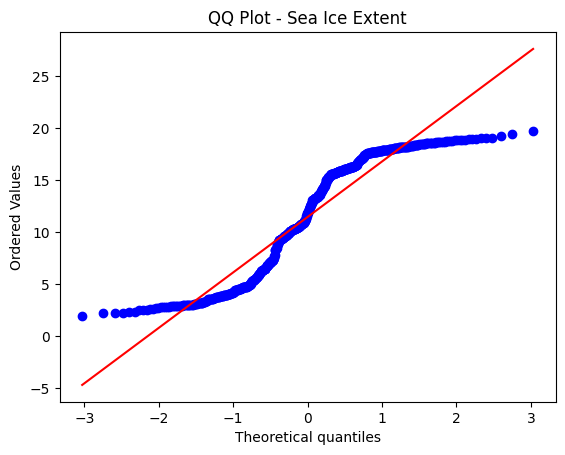

In [28]:
stats.probplot(df['Extent'], dist="norm", plot=plt)
plt.title("QQ Plot - Sea Ice Extent")
plt.show()

In [29]:
features = df[['Extent', 'Area']]
scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
principal = pca.fit_transform(scaled)

print(pca.explained_variance_ratio_)

[0.9979064 0.0020936]


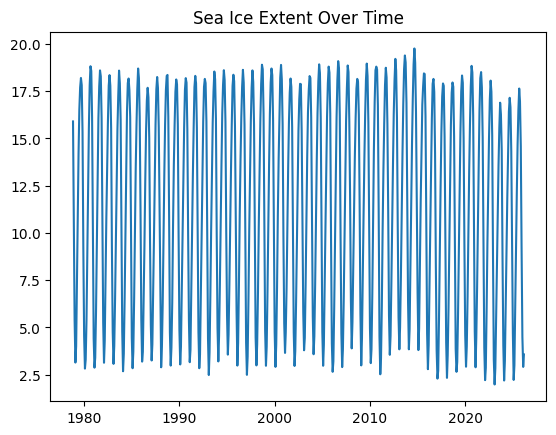

In [30]:
plt.figure()
plt.plot(df['Date'], df['Extent'])
plt.title("Sea Ice Extent Over Time")
plt.show()

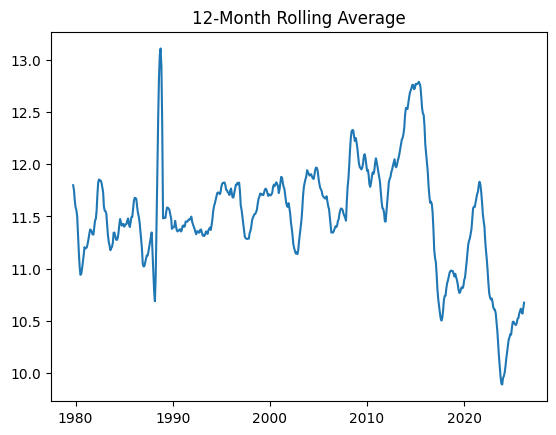

In [31]:
plt.figure()
plt.plot(df['Date'], df['Rolling_12'])
plt.title("12-Month Rolling Average")
plt.show()

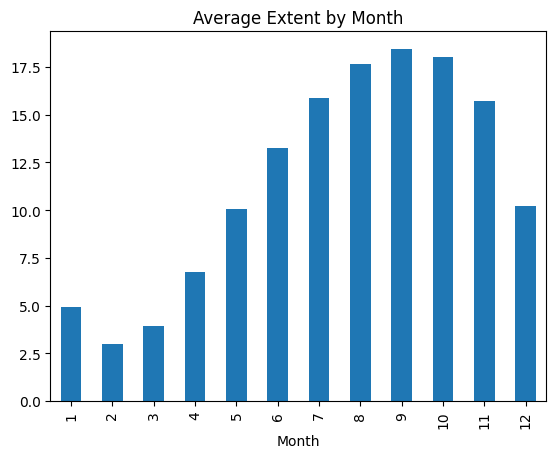

In [32]:
monthly_avg = df.groupby('Month')['Extent'].mean()

plt.figure()
monthly_avg.plot(kind='bar')
plt.title("Average Extent by Month")
plt.show()

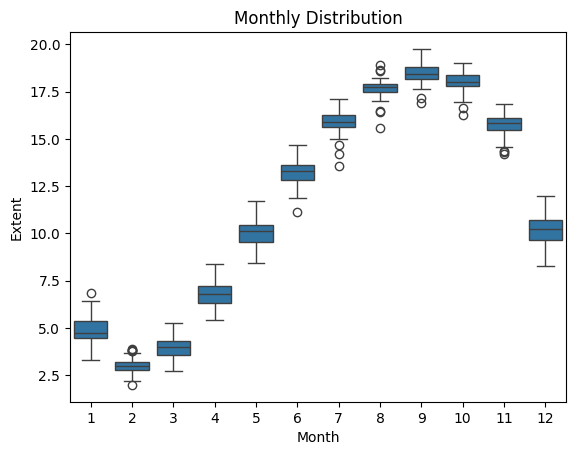

In [33]:
plt.figure()
sns.boxplot(x='Month', y='Extent', data=df)
plt.title("Monthly Distribution")
plt.show()

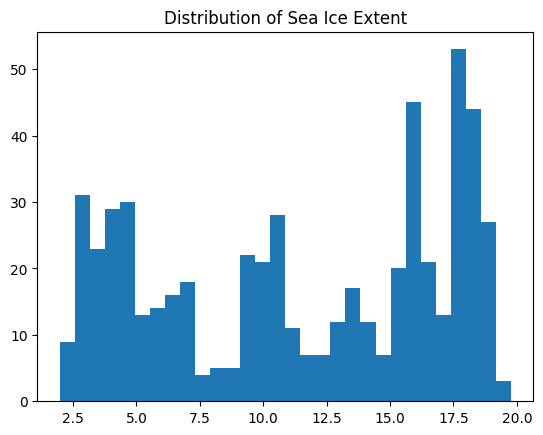

In [34]:
plt.figure()
plt.hist(df['Extent'], bins=30)
plt.title("Distribution of Sea Ice Extent")
plt.show()

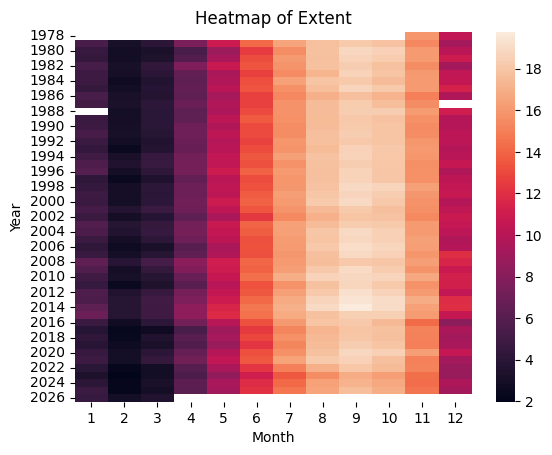

In [35]:
pivot = df.pivot_table(values='Extent', index='Year', columns='Month')

plt.figure()
sns.heatmap(pivot)
plt.title("Heatmap of Extent")
plt.show()

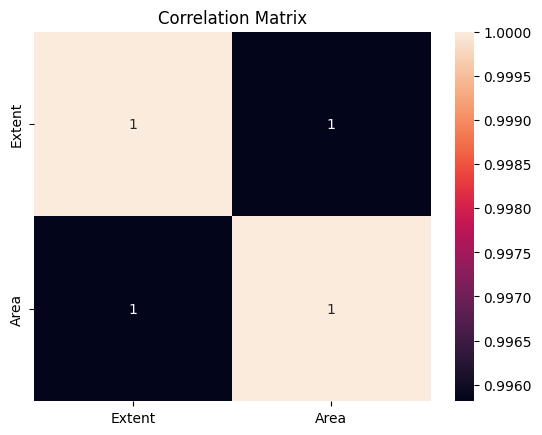

In [36]:
plt.figure()
sns.heatmap(df[['Extent','Area']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

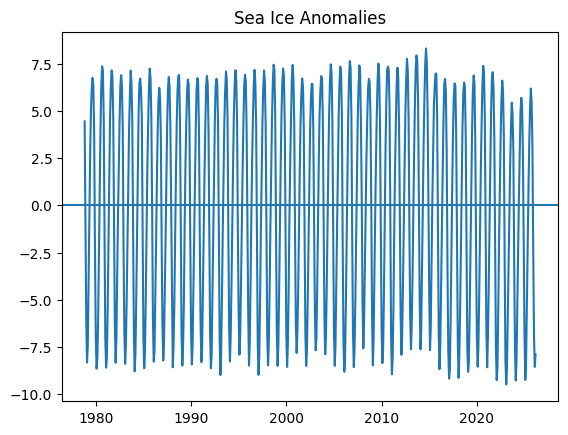

In [37]:
plt.figure()
plt.plot(df['Date'], df['Anomaly'])
plt.axhline(0)
plt.title("Sea Ice Anomalies")
plt.show()

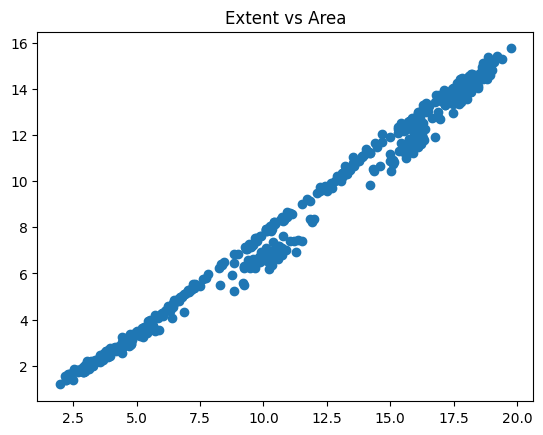

In [38]:
plt.figure()
plt.scatter(df['Extent'], df['Area'])
plt.title("Extent vs Area")
plt.show()

In [39]:
df_clean = df.copy()

In [40]:

numeric_cols = df_clean.select_dtypes(include=['float64','int64']).columns

summary_stats = pd.DataFrame({
    'Count': df_clean[numeric_cols].count(),
    'Mean': df_clean[numeric_cols].mean(),
    'Median': df_clean[numeric_cols].median(),
    'Variance': df_clean[numeric_cols].var(),
    'Std Dev': df_clean[numeric_cols].std(),
    'Min': df_clean[numeric_cols].min(),
    'Max': df_clean[numeric_cols].max(),
    '25% Quantile': df_clean[numeric_cols].quantile(0.25),
    '50% Quantile': df_clean[numeric_cols].quantile(0.5),
    '75% Quantile': df_clean[numeric_cols].quantile(0.75),
    'Skewness': df_clean[numeric_cols].skew(),
    'Kurtosis': df_clean[numeric_cols].kurt()
})

summary_stats

,Count,Mean,Median,Variance,Std Dev,Min,Max,25% Quantile,50% Quantile,75% Quantile,Skewness,Kurtosis
Year,567,2.002093e+03,2002.000000,187.685593,13.699839,1978.000000,2026.000000,1990.000000,2002.000000,2014.000000,-0.006790,-1.195280
Month,567,6.493827e+00,6.000000,11.967718,3.459439,1.000000,12.000000,3.000000,6.000000,9.500000,0.003536,-1.223302
Extent,567,1.146296e+01,11.850000,31.231666,5.588530,1.980000,19.760000,5.745000,11.850000,16.700000,-0.205086,-1.461144
Area,567,8.685750e+00,9.030000,21.084083,4.591741,1.190000,15.750000,4.035000,9.030000,13.165000,-0.148152,-1.494743
Rolling_12,556,1.150125e+01,11.505833,0.285774,0.534579,9.889167,13.110000,11.286667,11.505833,11.799583,-0.193488,0.908450
Anomaly,567,-6.453783e-16,0.387037,31.231666,5.588530,-9.482963,8.297037,-5.717963,0.387037,5.237037,-0.205086,-1.461144
Log_Extent,567,2.274103e+00,2.472328,0.395114,0.628581,0.683097,2.983660,1.748320,2.472328,2.815404,-0.722070,-0.835982
Extent_scaled,567,-1.182671e-16,0.069317,1.001767,1.000883,-1.698360,1.485966,-1.024064,0.069317,0.937932,-0.205086,-1.461144


In [41]:
df_raw = df.copy()
df.replace(-9999, np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.rename(columns={'extent':'Extent','area':'Area'}, inplace=True)
df.to_csv("antarctic_sea_ice_cleaned.csv", index=False)
df_clean = df.copy()

In [42]:
missing_before = df_raw.replace(-9999, np.nan).isnull().sum().sum()
duplicates_before = df_raw.duplicated().sum()
missing_after = df_clean.isnull().sum().sum()
duplicates_after = df_clean.duplicated().sum()

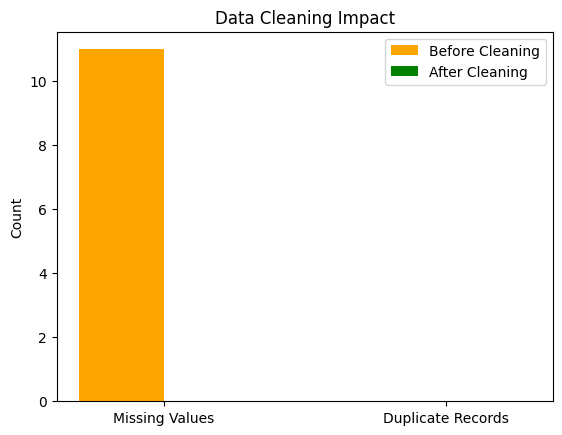

In [43]:
import matplotlib.pyplot as plt

missing_before = df_raw.isnull().sum().sum()
duplicates_before = df_raw.duplicated().sum()

missing_after = df_clean.isnull().sum().sum()
duplicates_after = df_clean.duplicated().sum()

labels = ['Missing Values', 'Duplicate Records']
before = [missing_before, duplicates_before]
after = [missing_after, duplicates_after]

x = range(len(labels))
plt.bar([i-0.15 for i in x], before, width=0.3, label='Before Cleaning', color='orange')
plt.bar([i+0.15 for i in x], after, width=0.3, label='After Cleaning', color='green')
plt.xticks(x, labels)
plt.ylabel("Count")
plt.title("Data Cleaning Impact")
plt.legend()
plt.show()

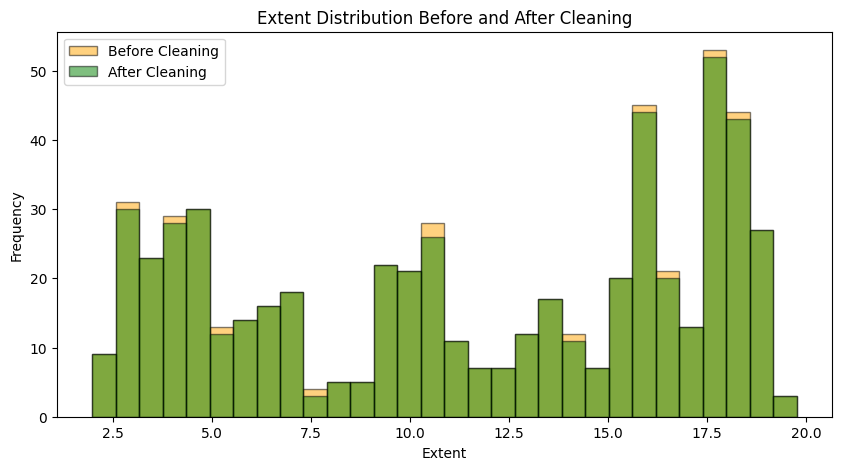

In [44]:
plt.figure(figsize=(10,5))
plt.hist(df_raw['Extent'].replace(-9999,np.nan).dropna(), bins=30, color='orange', edgecolor='black', alpha=0.5, label='Before Cleaning')
plt.hist(df_clean['Extent'], bins=30, color='green', edgecolor='black', alpha=0.5, label='After Cleaning')
plt.title("Extent Distribution Before and After Cleaning")
plt.xlabel("Extent")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
X = df[['Year','Month']]
y = df['Extent']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
rf = RandomForestRegressor(
    n_estimators=200,     # number of trees
    max_depth=10,         # control overfitting
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [49]:
y_pred = rf.predict(X_test)

In [50]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.30245321191881586
RMSE: 0.5499574637358928
R2 Score: 0.9897163274971645


In [51]:
df_sorted = df.sort_values(by=['Year','Month']).copy()

df_sorted['Predicted'] = rf.predict(df_sorted[['Year','Month']])

In [52]:
yearly_df = df_sorted.groupby('Year').agg({
    'Extent': 'mean',
    'Predicted': 'mean'
}).reset_index()

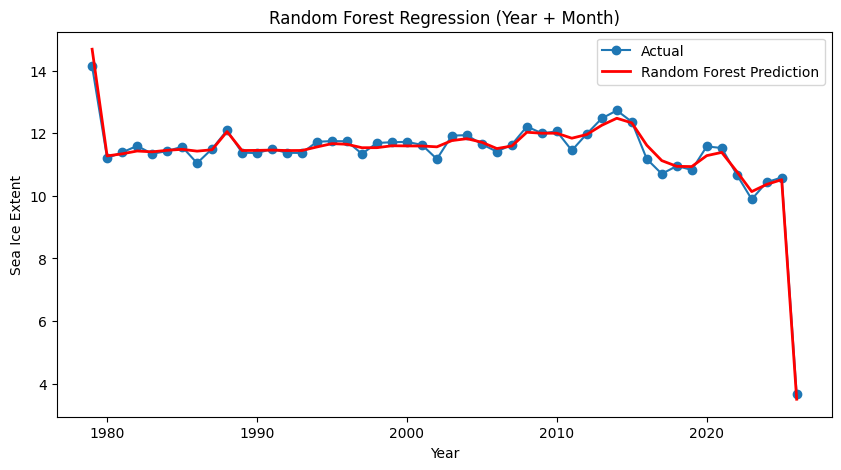

In [53]:
plt.figure(figsize=(10,5))

plt.plot(yearly_df['Year'], yearly_df['Extent'], marker='o', label='Actual')
plt.plot(yearly_df['Year'], yearly_df['Predicted'], color='red', linewidth=2, label='Random Forest Prediction')

plt.xlabel("Year")
plt.ylabel("Sea Ice Extent")
plt.title("Random Forest Regression (Year + Month)")
plt.legend()
plt.show()

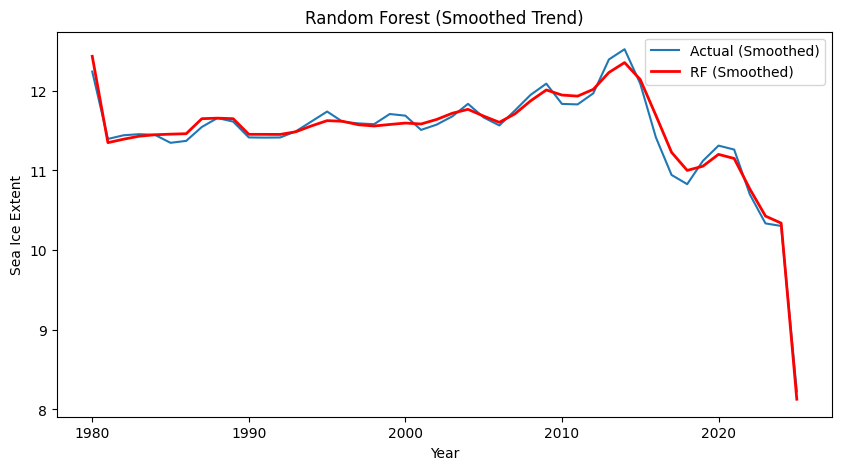

In [54]:
yearly_df['Smooth_Actual'] = yearly_df['Extent'].rolling(3, center=True).mean()
yearly_df['Smooth_Pred'] = yearly_df['Predicted'].rolling(3, center=True).mean()

yearly_clean = yearly_df.dropna()

plt.figure(figsize=(10,5))

plt.plot(yearly_clean['Year'], yearly_clean['Smooth_Actual'], label='Actual (Smoothed)')
plt.plot(yearly_clean['Year'], yearly_clean['Smooth_Pred'], color='red', linewidth=2, label='RF (Smoothed)')

plt.xlabel("Year")
plt.ylabel("Sea Ice Extent")
plt.title("Random Forest (Smoothed Trend)")
plt.legend()
plt.show()

In [55]:
month_counts = df.groupby('Year')['Month'].nunique()
print(month_counts.tail(10))

Year
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
2026     3
Name: Month, dtype: int64


In [56]:
valid_years = month_counts[month_counts == 12].index

df_filtered = df[df['Year'].isin(valid_years)]

In [57]:
df_sorted = df_filtered.sort_values(by=['Year','Month']).copy()

df_sorted['Predicted'] = rf.predict(df_sorted[['Year','Month']])

yearly_df = df_sorted.groupby('Year').agg({
    'Extent': 'mean',
    'Predicted': 'mean'
}).reset_index()

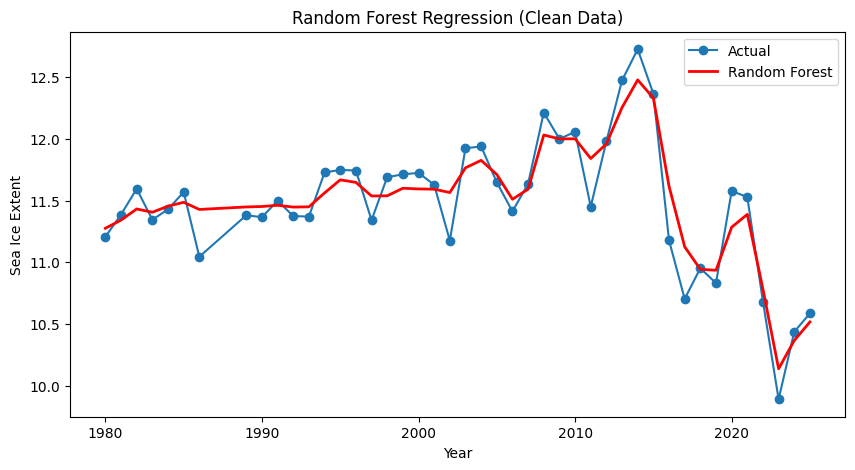

In [58]:
plt.figure(figsize=(10,5))

plt.plot(yearly_df['Year'], yearly_df['Extent'], marker='o', label='Actual')
plt.plot(yearly_df['Year'], yearly_df['Predicted'], color='red', linewidth=2, label='Random Forest')

plt.xlabel("Year")
plt.ylabel("Sea Ice Extent")
plt.title("Random Forest Regression (Clean Data)")
plt.legend()
plt.show()